# Plot best performing models from control runs

In [18]:
# input files
pmodelsfiles = '../control_run/hiscores_top.dict'
outfile = '../control_run/highScores_ewk'
truthfile = '../control_run/truth.dict'
nmodels = 10

In [3]:
# the imports

import sys,os,copy,glob
import numpy as np
sys.path.append(os.path.abspath('../smodels'))
sys.path.append(os.path.abspath('../'))
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from tester.predictor import Predictor
from tester.combiner import Combiner
from walker.hiscores import Hiscores
from smodels.experiment.databaseObj import Database
from smodels.base.physicsUnits import fb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from names import particleLabels
from sparticleNames import SParticleNames

In [108]:
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from walker.randomWalker import RandomWalker
import matplotlib.pyplot as plt
from tester.predictor import Predictor
from tester.combiner import Combiner
from tester.critic import Critic
from smodels.matching.theoryPrediction import TheoryPredictionsCombiner
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Palatino'
plt.rcParams['font.weight'] = '700'
plt.rcParams['axes.labelweight'] = '700'

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [5]:
#Set colors:
allPids = [1000022, 1000006, 1000001, 1000021, 1000012, 1000023, 
            1000013, 2000006, 1000011, 1000005, 1000014, 1000004, 1000015, 1000016, 1000024]
namer = SParticleNames ( susy = False )
colors = sns.color_palette('deep',n_colors=len(namer.xIDs))

#Replace default colors:
for pid in sorted(namer.xIDs.keys()):
    if not pid in allPids:
        allPids.append(pid)
colorDict = dict(zip(allPids,colors))
colorDict[1000002] = colorDict[1000001]
colorDict[1000003] = colorDict[1000001]
colorDict[1000004] = colorDict[1000001]

In [6]:
def getLikelihoods(protomodel,muvals,normalize=True):
    
    #Sort tpList
    critic = sorted(protomodel.tpList, key = lambda tp: tp[0], reverse = True)[0][2]

    #Combiner likelihood:
    combiner = Combiner(0)
    llhComb = np.array([combiner.getCombinedLikelihood(protomodel.bestCombo,mu) for mu in muvals])
    llhCombSM = combiner.getCombinedLikelihood(protomodel.bestCombo,0.)
    llhDict = {'Combined' : llhComb}
    llhDictSM = {'Combined' : llhCombSM}
    for tp in protomodel.bestCombo:
        llhDict[tp.expResult.globalInfo.id] = np.array([tp.getLikelihood(mu) for mu in muvals])
        llhDictSM[tp.expResult.globalInfo.id] = tp.getLikelihood(0.0)

    #Critic likelihood:
    if critic.getLikelihood(1.0) is not None:
        llhDictSM['Critic'] = critic.getLikelihood(0.0)
        llhDict['Critic'] = np.array([critic.getLikelihood(mu) for mu in muvals])
    else:
        llhDict['Critic'] = None
        llhDictSM['Critic'] = None
    llhDict['SM values'] = llhDictSM
    
    #Compute normalizations:
    if normalize:
        for key,llhd in llhDict.items():
            if key != 'SM values':
                norm = llhd.sum()
                llhDict[key] = llhd/norm
                llhDict['SM values'][key] *= 1/norm
    
    
    return llhDict


In [7]:
def fromDict(inputDict):
    
    p = ProtoModel(walkerid=0)
    for key,v in inputDict.items():
        setattr(p,key,copy.deepcopy(v))
        
    return p

In [8]:
pBest = None

In [89]:
#Get highest score from each run:

protomodelsDict = []
#for ff in glob.glob(pmodelsfiles):
with open(pmodelsfiles,'r') as f:
    pList = eval(f.read())
    print(len(pList))
    for p in pList:
        if p['step'] < 1000: continue  #wait for 1000 steps as burn-in 
        walk = p['walkerid']
        #print ( f"pDict {list(pList)[0]}" )
        #pList = [fromDict(pDict) for pDict in pList[:]]
        #p = sorted(pList, key = lambda p: p["K"], reverse=True)[0]
        protomodelsDict.append(p)
        if pBest is None or pBest["K"] < p["K"]:
            pBest = p


protomodelsDict = sorted(protomodelsDict, key = lambda p: p['K'], reverse=True)[:10]

20
722
721
727
725
731
733
728
723
729
730
734
740
732
724
736


In [110]:
rvars = { "walkerid": 0, "jmin": 0, "continueFrom": "",
                 "cheatcode": "no_cheat", "maxsteps": 1000, 
                 "cap_ssm": 100.,
                 "test_param_space": False, "seed": None, "expected": False,
                 "record_history": False, "catch_exceptions": True,
                 "stopTeleportationAfter": -1,
                 "run_mcmc": False }
from base.runEnviron import RunEnviron
RunEnviron.create()
environ = RunEnviron()
pTrue = None
with open ( truthfile, "rt" ) as f:
    pTrue = eval(f.read())

pTrue['K']=13.3
pTrue
ma = Manipulator(pTrue, environ=environ)
rw = RandomWalker(environ=environ, rvars=rvars)
pr = Predictor(0, environ=environ)
co = Combiner()
rw.predict(manipulator=ma)
best_comb = TheoryPredictionsCombiner(pTrue.bestCombo)

[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W
False
[randomWalker:0] Ramping up with slurm jobid unknown
[randomWalker:0] It is Fri Dec 12 17:19:20 2025
[randomWalker:0] template /Users/sahananarasimha/protomodels/builder/templates/template_default.slha allowN1N1 True susy_mode False
ProtoModel (X1Z): K = None, TL = 0.0


NameError: name 'proto' is not defined

In [124]:
best_comb = TheoryPredictionsCombiner(ma.M.bestCombo)
#comb_all = [comb.analysisId() for comb in best_comb]
pTrue['description'] = best_comb.analysisId()
pTrue['description'] ='ATLAS-EXOT-2018-06(em),ATLAS-SUSY-2013-11(em),ATLAS-SUSY-2013-12(em),ATLAS-SUSY-2018-05-ewk(comb),ATLAS-SUSY-2018-06,ATLAS-SUSY-2018-32(comb),CMS-EXO-20-004(comb),CMS-SUS-13-012(em),CMS-SUS-16-039-agg(comb)'



In [139]:
pTrue['decays']

{1000022: {}, 1000023: {(1000022, 23): 1.0}, 1000024: {(1000022, 24): 1.0}}

In [125]:
#Get all particles which appears in all models:
particles = []
#modelList = list(protomodelsDict.items())
modelList = protomodelsDict
#modelList = sorted(modelList, key = lambda pt: pt[0])
modelList = [pTrue] + modelList[:] #Add winning protomodel as run 0
modelList = np.array(modelList)
walkerid_values = np.array(["Truth"]+[f"{int(proto['walkerid'])%700}:{proto['step']}" for proto in protomodelsDict])
modelList = modelList[:nmodels+1]
for p in modelList:
    particles += list(p["masses"].keys())
    ana = p['description'].split(',')
    analyses += ana

particles = list(set(particles))
analyses = sorted(list(set(analyses)))

#Build useful dataset:
nparticles = np.array([len(p["masses"].keys() ) for p in modelList])
Kvalues = np.array([p["K"] if (p["K"] and p["K"] > 0) else 0.0 for p in modelList])
Zvalues = np.array([p["TL"] if (p["TL"] and p["TL"] > 0) else 0.0 for p in modelList])
masses = dict([[pid,[]] for pid in particles])
for p in modelList:
    for pid in masses:
        if pid in p["masses"]:
            masses[pid].append(p["masses"][pid])
        else:
            masses[pid].append(-100.0)
for pid in masses:
    masses[pid] = np.array(masses[pid])
dataDict = {'walkerid' : walkerid_values, 'K' : Kvalues,
                   'nparticles' : nparticles}
dataDict.update(masses) 

bestCombo_values = np.array([proto['description'] for proto in modelList])
dataDict.update({"bestCombo":bestCombo_values}) 


df = pd.DataFrame(dataDict)

In [77]:
df['walkerid'][0]

'Truth'

In [129]:
df[1000023] - df[1000022]
np.mean(df[1000023][1:] - df[1000022][1:])

146.62556299172576

In [43]:
for run in sorted(protomodelsDict.keys()):
    print( f'walk={run} K={protomodelsDict[run]["K"]}, step={protomodelsDict[run]["step"]}' )

Karr = np.array([p["K"] for p in protomodelsDict.values()])
Kavg = Karr.mean()
Kstd = Karr.std()
Kmin = min ( Karr )
print('K (avg) = %1.2f +- %1.2f' %(Kavg,Kstd))

walk=721 K=21.198302, step=1496
walk=722 K=24.002566, step=7250
walk=725 K=20.682933, step=2150
walk=727 K=20.792228, step=3126
walk=731 K=20.529882, step=13416
walk=733 K=20.423285, step=14229
walk=735 K=20.81775, step=457
walk=737 K=21.795399, step=20
walk=738 K=21.874669, step=622
walk=739 K=20.601567, step=715
K (avg) = 21.27 +- 1.03


In [69]:
colorDict = {}
colorDict[1000022] = 'dodgerblue'
colorDict[1000023] = 'blue'
colorDict[1000025] = 'navy'

colorDict[1000024] = 'limegreen'
colorDict[1000037] = 'darkgreen'

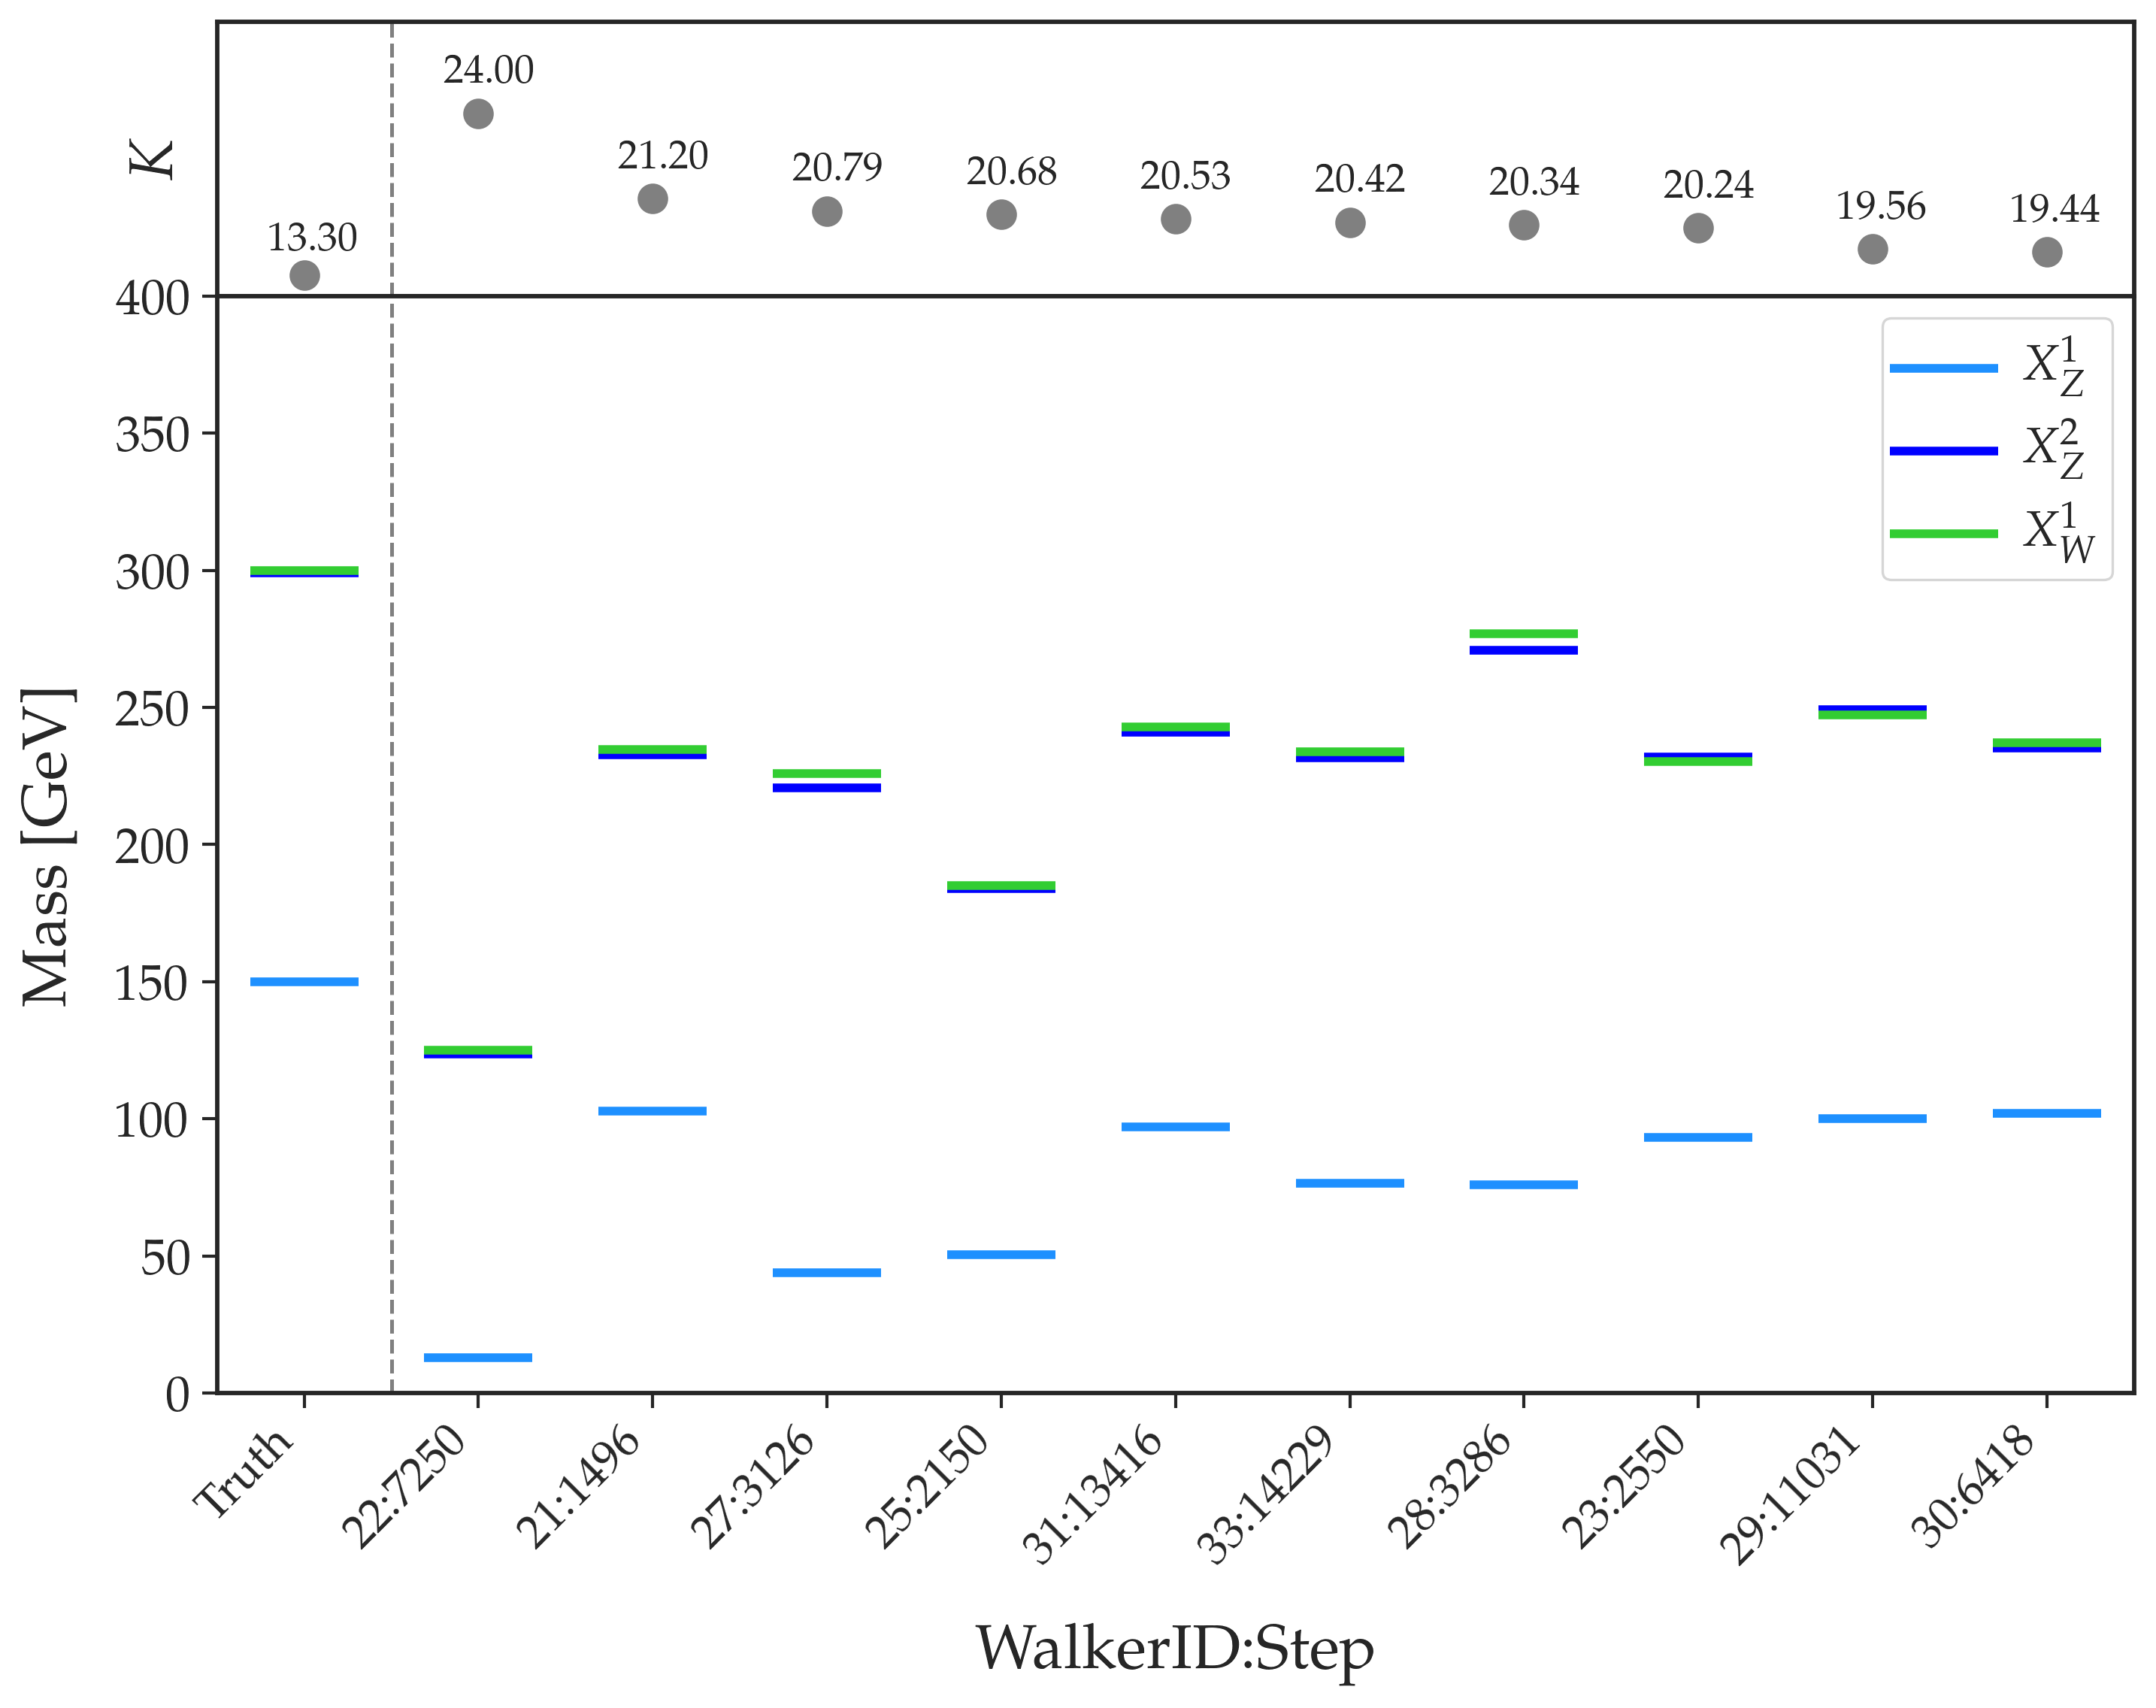

In [136]:
particleLabels[1000024] = "X_{W}^{1}"
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
axarr[0].set_ylabel(r'$K$', fontsize=20)
axarr[0].set_ylim(18.0,27.0)
axarr[0].set_yticks([])

pids = sorted(list(masses.keys()))

for i,row in df.iterrows():
    axarr[0].annotate(rf'{row["K"]:1.2f}',(runs[i]-.2,(row["K"]) + 1),fontsize=13)
    if i==0:
        axarr[0].annotate(rf'{row["K"]:1.2f}',(runs[i]-.2,19.5),fontsize=13)
        axarr[0].scatter(df['walkerid'][0],18.7,s=80,c='gray')
#    axarr[0].annotate(r'$%1.2f$' %row['K'],(row['run']-0.2,row['K']+0.8),fontsize=13)


axarr[0].vlines(x=0.5,ymin=18,ymax=27,linestyle='--',color='gray')

for pid in pids:    
    data = df
    if pid ==1000023:
        sns.scatterplot(x=[0],y=data[pid][0]-1, s=1200, marker='_', legend=False,c=[colorDict[pid]],ax=axarr[1])
        sns.scatterplot(x=data['walkerid'][1:],y=data[pid][1:], s=1200, marker='_',label=r'$%s$' %(particleLabels[pid]), legend=True,c=[colorDict[pid]],ax=axarr[1])
    else:
        sns.scatterplot(x=data['walkerid'],y=data[pid], s=1200, marker='_',label=r'$%s$' %(particleLabels[pid]), legend=True,c=[colorDict[pid]],ax=axarr[1])
    #index = [np.where(walkerid_values == d['walkerid'])[0][0] for j,d in data.iterrows()]


axarr[1].set_ylim(0.,400.0)
axarr[1].set_xlabel('WalkerID:Step', fontsize=20, labelpad=15)
axarr[1].set_ylabel('Mass [GeV]', fontsize=20, labelpad=10)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=15, rotation=45, ha='right')
axarr[1].vlines(x=0.5,ymin=0,ymax=400,linestyle='--',color='gray')
#     plt.plot(df['run'],m,'-',linewidth=2)

leg = axarr[1].legend()
plt.setp(leg.get_texts(), fontsize=16)
plt.ylim(0.,400.0)



# plt.grid(axis='x') 
# plt.legend(loc=(0.8,0.85),framealpha=1.0,ncol=3,labelspacing=0.1,
#            handlelength=0.4,handletextpad=0.35,markerscale=0.8,columnspacing=1.0)
# plt.tight_layout()
#plt.savefig(outfile+".pdf")
#plt.savefig(outfile+".png")
plt.show()

['ATLAS-SUSY-2013-12(em)', 'ATLAS-SUSY-2018-05-ewk(comb)', 'ATLAS-SUSY-2019-02(comb)', 'CMS-SUS-21-002(comb)', 'ATLAS-SUSY-2013-11(em)', 'ATLAS-EXOT-2018-06(em)', 'ATLAS-SUSY-2018-32(comb)', 'CMS-SUS-13-012(em)', 'CMS-EXO-20-004(comb)', 'ATLAS-SUSY-2019-09(comb)', 'CMS-SUS-16-039-agg(comb)', 'ATLAS-SUSY-2018-06']


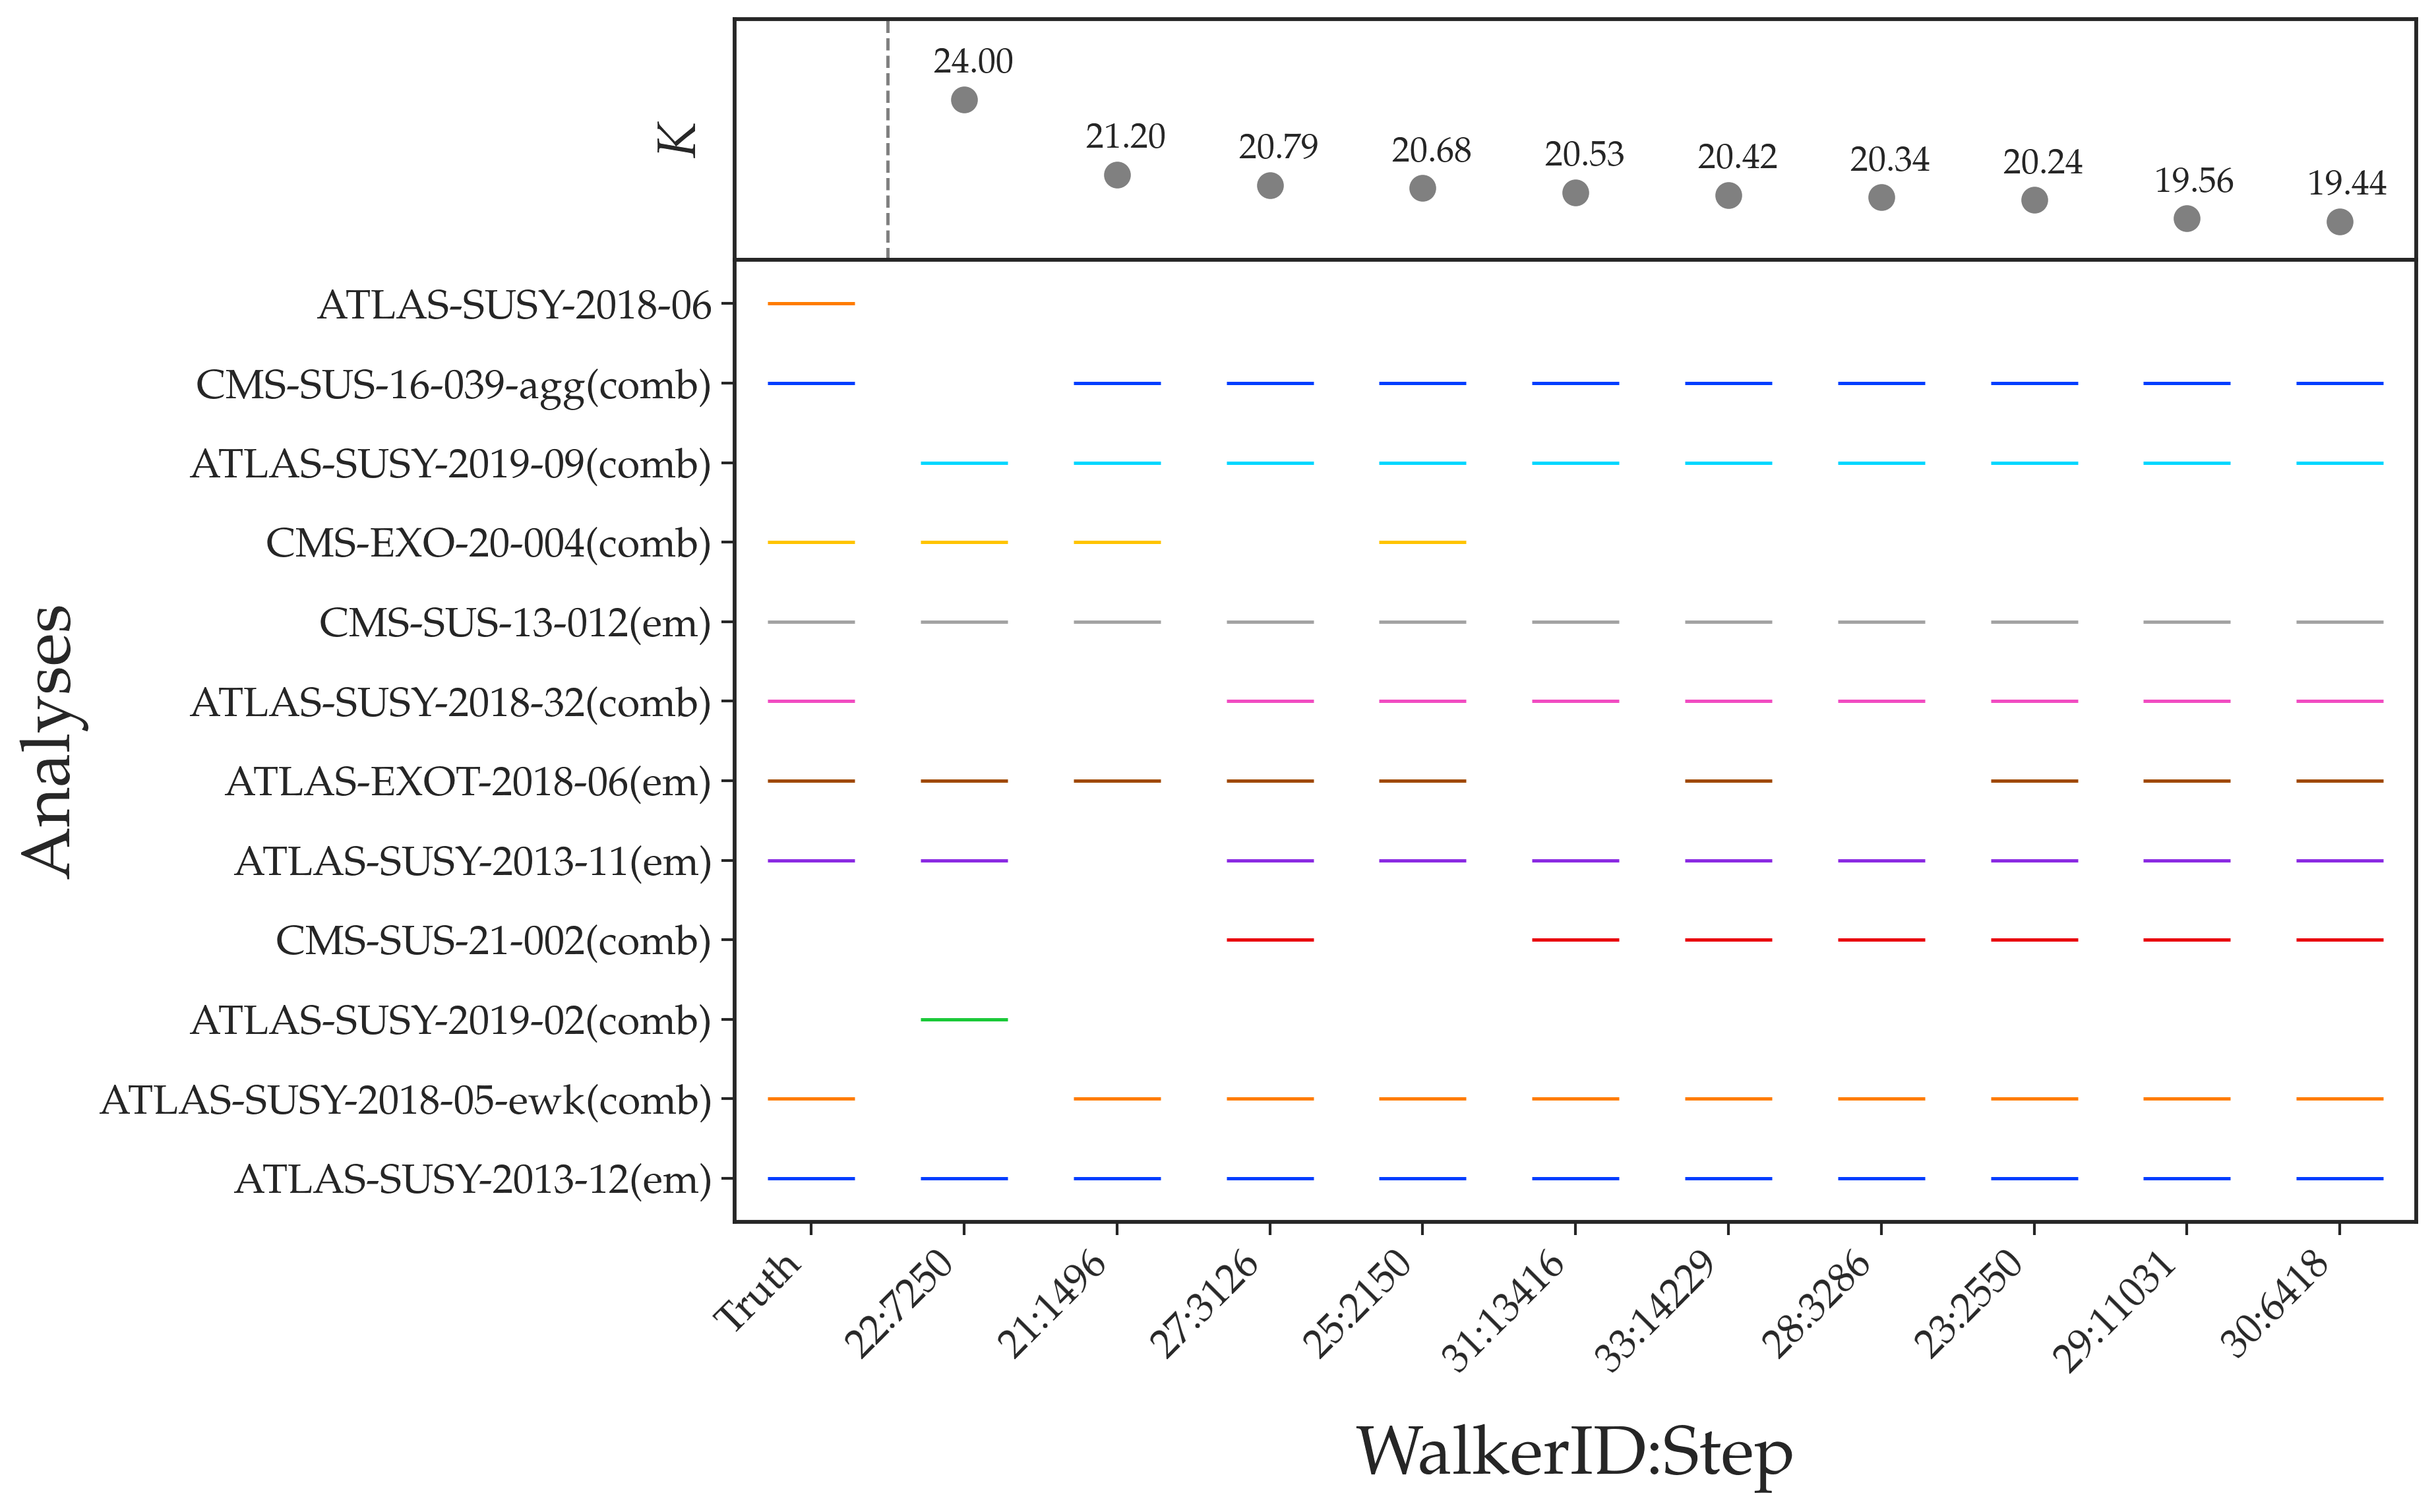

In [126]:
def color_analyses(comb_list):

    colors = sns.color_palette('bright',n_colors=len(comb_list))
    colorAna = {}
    '''
    colorAna['ATLAS-EXOT-2018-06(em)'] = 'dodgerblue'
    colorAna['CMS-EXO-20-004(comb)'] = 'limegreen'
    colorAna['ATLAS-SUSY-2018-41(comb)'] = 'orange'
    colorAna['CMS-SUS-13-012(em)'] = 'crimson'
    colorAna['CMS-SUS-20-004(comb)'] = 'red'
    colorAna['ATLAS-SUSY-2013-11(em)'] = 'darkgreen'
    colorAna['ATLAS-SUSY-2016-24(em)'] = 'brown'
    colorAna['ATLAS-SUSY-2019-08(comb)'] = 'purple'
    colorAna['CMS-SUS-16-039-agg(comb)'] = 'blue'
    #['ATLAS-EXOT-2018-06(em)', 'CMS-SUS-16-039-agg(comb)', 'ATLAS-SUSY-2018-41(comb)', 'ATLAS-SUSY-2013-11(em)', 'CMS-SUS-20-004(comb)', 'CMS-EXO-20-004(comb)', 'ATLAS-SUSY-2016-24(em)', 'CMS-SUS-13-012(em)', 'ATLAS-SUSY-2019-08(comb)']
    '''
    colorAna = dict(zip(comb_list,colors))
    return colorAna


f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)


nsteps = 10

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
axarr[0].set_ylabel(r'$K$', fontsize=20)
axarr[0].set_ylim(18.0,27.0)
axarr[0].set_yticks([])

pids = sorted(list(masses.keys()))

for i,row in df.iterrows():
    axarr[0].annotate(rf'{row["K"]:1.2f}',(runs[i]-.2,(row["K"]) + 1),fontsize=13)
#    axarr[0].annotate(r'$%1.2f$' %row['K'],(row['run']-0.2,row['K']+0.8),fontsize=13)


axarr[0].vlines(x=0.5,ymin=18,ymax=27,linestyle='--',color='gray')


comb_list = set()
for i,row in df.iterrows():
    bC = sorted(row['bestCombo'].split(','))
    #print(bC)
    for b in bC: comb_list.add(b)

#sortedAna = ['ATLAS-EXOT-2018-06(em)','CMS-EXO-20-004(comb)','CMS-SUS-20-004(comb)', 'CMS-SUS-13-012(em)', 'ATLAS-SUSY-2018-41(comb)', 'ATLAS-SUSY-2013-11(em)', 'ATLAS-SUSY-2016-24(em)', 'ATLAS-SUSY-2019-08(comb)', 'CMS-SUS-16-039-agg(comb)']
comb_list = list(comb_list)
print(comb_list)
y_positions = list(range(len(comb_list)))
axarr[1].set_yticks(y_positions)
axarr[1].set_yticklabels(comb_list,  fontsize=15)

colorAna = color_analyses(comb_list)
for i,row in df.iterrows():
    bC = sorted(row['bestCombo'].split(','))
    for j, b in enumerate(bC):
        y_position = [ind for (ind,cA) in zip(y_positions, comb_list) if cA==b][0]
        axarr[1].scatter(row['walkerid'], y_position, marker='_', s=1000, c=[colorAna[b]] )
        index2 = analyses.index(b)
        #axarr[1].annotate(f'{b}',(index-0.2,index2),fontsize=10)
axarr[1].set_xlabel('WalkerID:Step', fontsize=25, labelpad=15)
axarr[1].set_ylabel('Analyses', fontsize=25)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()), fontsize=15, rotation=45, ha='right')


plt.show()